In [2]:
import numpy as np
import matplotlib.pyplot as plt
import zfit
import cmath
import math
import scipy
import hist
from hist import Hist
import functools
import matplotlib.animation as animation

/home/quarktop/.venv/lib/python3.10/site-packages/zfit/__init__.py:93: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [3]:
## LIFETIMES AND DECAY
k_s_tau = 8.958e-11
k_l_tau = 5.116e-8

gamma_s = 1/(k_s_tau)
gamma_l = 1/(k_l_tau)

delta_gamma = (gamma_s-gamma_l)*1e-9

delta_m = 5.293

## true epsilon

epsilon = cmath.rect(2.264e-3, math.radians(43.19))

In [4]:
# MIXING ASYMMETRY FOR NEUTRAL KAONS

def A_t(t):
    abs_e = abs(epsilon)
    phi   = cmath.phase(epsilon)

    exp_half = np.exp(0.5 * delta_gamma * t)
    exp_full = np.exp(delta_gamma * t)

    numer = 2.0 * abs_e * exp_half * np.cos(delta_m * t - phi)
    denom = 1.0 + (abs_e**2) * exp_full

    return  -1* numer / denom

A_t_vec = np.vectorize(A_t)

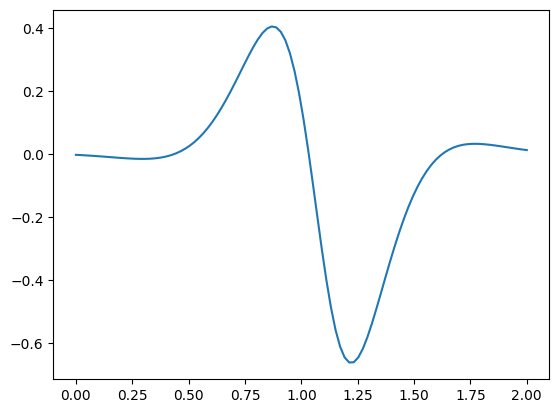

In [5]:
N = 100
tmax = 2
time_array = np.linspace(0, 2, N)
A_true  = A_t_vec(time_array)

plt.plot(time_array, A_true)

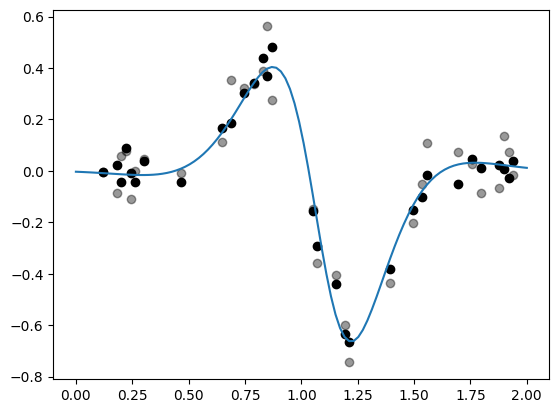

In [6]:
plt.plot(time_array, A_true)

time_event = time_array[np.random.uniform(0,1,N)>0.6]
sigma=0.05
noise = np.random.normal(0, sigma, size=time_event.size)
A_measured = A_t_vec(time_event) + noise

plt.scatter(time_event, A_measured, c='black')


noise = np.random.normal(0, 0.1, size=time_event.size)
A_measured = A_t_vec(time_event) + noise

plt.scatter(time_event, A_measured, c='black', alpha=0.4)


In [7]:

## N_events = numero de eventos, select = % de eventos selecionados, 
def random_sampling_with_error(sigma, N_events=100, select=0.6):
    time_array_true = np.linspace(0, 2, N_events)
    
    mask = np.random.rand(N_events) < select
    time_event = time_array_true[mask]

    noise = np.random.normal(0, sigma, size=time_event.size)
    A_event = A_t_vec(time_event) + noise

    return time_event, A_event

def A_minimizer(t, abs_e, phi):
    
    exp_half = np.exp(0.5 * delta_gamma * t)
    exp_full = np.exp(delta_gamma * t)

    numer = 2.0 * abs_e * exp_half * np.cos(delta_m * t - phi)
    denom = 1.0 + (abs_e**2) * exp_full

    return  -1* numer / denom

def run_minimizer(sigma=0.02):    
    time_event, A_event = random_sampling_with_error(sigma)
    
    try:
        popt, pcov = scipy.optimize.curve_fit(A_minimizer, time_event, A_event, p0=[2e-3, np.radians(45)])
        return popt, np.diag(pcov)
    except RuntimeError:
        return None, None

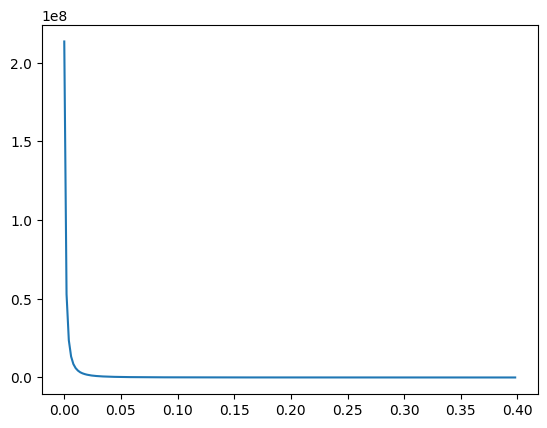

In [8]:
sigmas = np.linspace(0.00, 0.4, 200)
sig_vec = []
dist_sample = [[]]
e_abs_list = []
for sgm in sigmas:
    var_vals = []
    var_errs = []
    for i in range(5000):
        popt, errs =  run_minimizer(sigma=sgm)

        if popt is None:
            i -= 1
        else:    
            var_vals.append(popt)
            var_errs.append(errs)

    results = np.array(var_vals)
    e_abs = results[:, 0]
    e_phi = results[:, 1]
    erros = np.array(var_errs)
    e_phi_err = erros[:,1]
    e_abs_err = erros[:,0]        

    e_abs_list.append(e_abs)

    if(sgm==0.00):
        continue
    else:
        significance = np.mean(np.abs(np.array(e_abs)) / np.array(e_abs_err))
        sig_vec.append(significance)

e_abs_array = np.array(e_abs_list, dtype=object)
plt.plot(sigmas[:-1], sig_vec)

In [9]:
hist_array = np.array([
    np.histogram(a, bins=100, range=(0.00, 0.005))[0]
    for a in e_abs_array
])

hist_array_norm = hist_array / hist_array.sum(axis=1, keepdims=True)

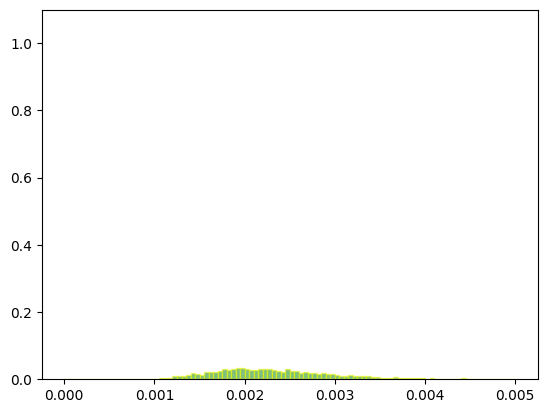

In [10]:
from matplotlib import rc
rc('animation', html='jshtml')

import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np
import functools


def animate(frame_number, bar_container):
    hist_frame = hist_array_norm[frame_number]
    for count, rect in zip(hist_frame, bar_container.patches):
        rect.set_height(count)
    return bar_container.patches

fig, ax = plt.subplots()

bin_edges = np.linspace(0.00, 0.005, hist_array_norm.shape[1] + 1)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

bars = ax.bar(
    bin_centers,
    hist_array[0],
    width=bin_width,
    color="green",
    edgecolor="yellow",
    alpha=0.5
)

ax.set_ylim(0, np.max(hist_array_norm)*1.1)

anim = functools.partial(animate, bar_container=bars)
ani = animation.FuncAnimation(fig, anim, frames=len(hist_array_norm), blit=True)

ani

the Kullback Leiber Divergence is given by $D_{KL}(P||Q)=\sum_{n}P_n\log\frac{P_n}{Q_n}$

In [11]:
def kullback(p, q):
    sum = 0
    for i in range(len(p)):
        if (p[i]!=0):
            sum += p[i]*np.log(p[i]/q[i])
    return sum

In [12]:
def gauss(x, s):
    return (1/np.sqrt(2*np.pi*s))*np.exp(-(1/(2*s))*(x-2.264e-3)**2)

In [13]:
DKL_array = []

for i in range(len(hist_array_norm)):

    DKL_array.append(kullback(hist_array_norm[0], hist_array_norm[i]))


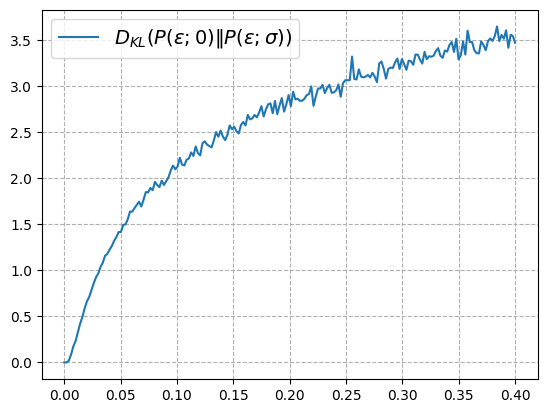

In [14]:
fig, ax = plt.subplots()
ax.plot(sigmas, DKL_array, label=r"$D_{KL}(P(\epsilon;0)\|P(\epsilon;\sigma))$")
ax.grid(True, linestyle='--')
ax.legend(fontsize=14)

plt.show()

In [15]:
var_array =[]
e_abs = abs(epsilon)
    
for i in range(len(hist_array_norm)):
    var = 0
    for j in range(len(hist_array_norm[i])):
        var += (hist_array_norm[i][j]*(bin_centers[j]-e_abs)**2)
    var_array.append(var)
    
var_array = np.array(var_array)

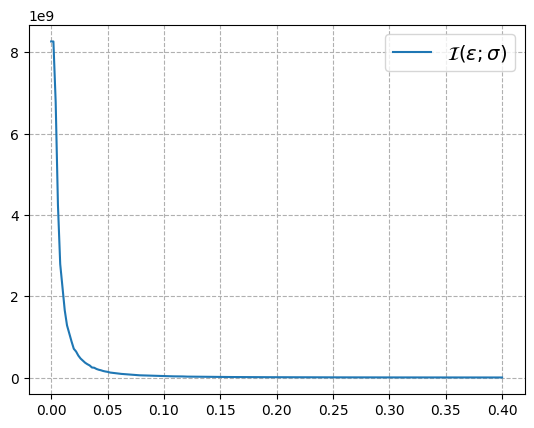

In [16]:
fig, ax = plt.subplots()
ax.plot(sigmas,1/var_array, label=r"$\mathcal{I}(\epsilon;\sigma)$")
ax.grid(True, linestyle='--')
ax.legend(fontsize=14)

plt.show()

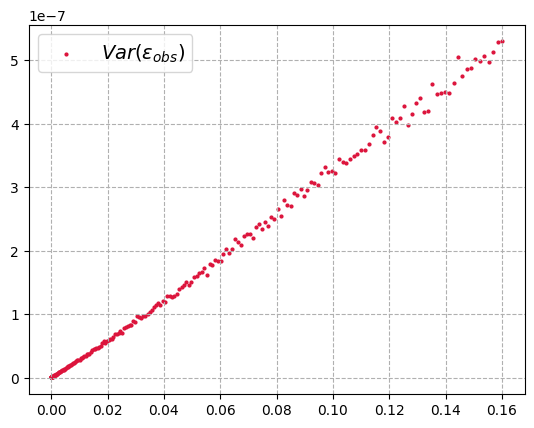

In [29]:
fig, ax = plt.subplots()
ax.scatter(sigmas**2,var_array, label=r"$Var(\epsilon_{obs})$", s=4, color="crimson")
ax.grid(True, linestyle='--')
ax.legend(fontsize=14)

plt.show()

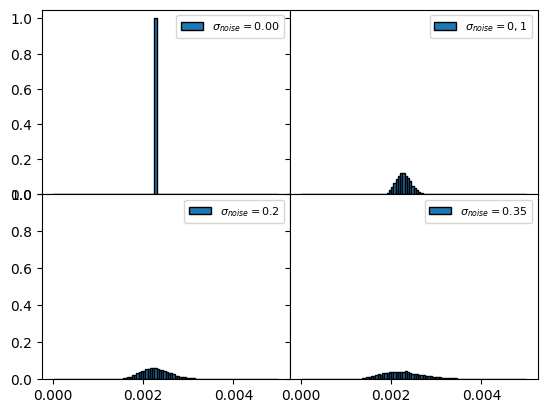

In [18]:
fig = plt.figure()
gs = fig.add_gridspec(2, 2, hspace=0, wspace=0)
(ax1, ax2), (ax3, ax4) = gs.subplots(sharex='col', sharey='row')
# Hide inner labels



# --- Plot the 4 histograms ---
ax1.bar(bin_centers, hist_array_norm[0],
        width=np.diff(bin_edges),
        align="center", edgecolor="black", label=r"$\sigma_{noise}=0.00$")

ax2.bar(bin_centers, hist_array_norm[50],
        width=np.diff(bin_edges),
        align="center", edgecolor="black", label=r"$\sigma_{noise}=0,1$")
# --- Set y-axis for bottom row ---
ax3.set_ylim(0, 1)
ax4.set_ylim(0, 1)


ax3.bar(bin_centers, hist_array_norm[100],
        width=np.diff(bin_edges),
        align="center", edgecolor="black", label=r"$\sigma_{noise}=0.2$")

ax4.bar(bin_centers, hist_array_norm[150],
        width=np.diff(bin_edges),
        align="center", edgecolor="black", label=r"$\sigma_{noise}=0.35$")

for ax in fig.get_axes():
    #ax.grid(True, linestyle='--')
    ax.label_outer()
    ax.legend(fontsize=8)

plt.show()